In [1]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
with zipfile.ZipFile("spambase.zip", "r") as z:
    with z.open("spambase.data") as f:
        df = pd.read_csv(f, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print("Dataset shape:", df.shape)

Dataset shape: (4601, 58)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [4]:
# Problem 1

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predictions

y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy and Error
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy

print("Accuracy:", accuracy)
print("Error:", error)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Print coefficients

coefficients = pd.DataFrame({
    "Feature_Index": range(len(model.coef_[0])),
    "Coefficient": model.coef_[0]
})

coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()

print("\nTop contributing features:")
print(coefficients.sort_values("Abs_Coefficient", ascending=False).head(10))

print("\nPositive correlation with spam:")
print(coefficients.sort_values("Coefficient", ascending=False).head(10))

print("\nNegative correlation with spam:")
print(coefficients.sort_values("Coefficient").head(10))

# Threshold analysis

y_prob = model.predict_proba(X_test)[:,1]

thresholds = [0.25,0.5,0.75,0.9]

for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)

    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)

    print("\nThreshold:", t)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)

Confusion Matrix:
 [[665  32]
 [ 52 402]]
Accuracy: 0.9270199826238054
Error: 0.07298001737619464
Precision: 0.9262672811059908
Recall: 0.8854625550660793
F1 Score: 0.9054054054054054

Top contributing features:
    Feature_Index  Coefficient  Abs_Coefficient
52             52     3.523587         3.523587
26             26    -3.389812         3.389812
22             22     1.961211         1.961211
45             45    -1.868817         1.868817
6               6     1.850217         1.850217
41             41    -1.821683         1.821683
34             34    -1.743550         1.743550
40             40    -1.579899         1.579899
24             24    -1.562423         1.562423
28             28    -1.411502         1.411502

Positive correlation with spam:
    Feature_Index  Coefficient  Abs_Coefficient
52             52     3.523587         3.523587
22             22     1.961211         1.961211
6               6     1.850217         1.850217
14             14     1.275319     

In [5]:
# Problem 2 

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
train_std[train_std == 0] = 1

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

X_train_bias = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_bias = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def cross_entropy_loss(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

def gradient_descent_logistic(X, y, lr=0.01, n_iter=100):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    losses = {}

    for i in range(1, n_iter + 1):
        z = X @ w
        y_prob = sigmoid(z)

        gradient = (X.T @ (y_prob - y)) / n_samples
        w = w - lr * gradient

        if i in [10, 50, 100]:
            loss = cross_entropy_loss(y, sigmoid(X @ w))
            losses[i] = loss

    return w, losses

def predict_proba(X, w):
    return sigmoid(X @ w)

def predict_class(X, w, threshold=0.5):
    return (predict_proba(X, w) >= threshold).astype(int)

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

# 3 learning rates
learning_rates = [0.001, 0.01, 0.1]

results = []

for lr in learning_rates:
    w, losses = gradient_descent_logistic(X_train_bias, y_train, lr=lr, n_iter=100)

    y_train_pred = predict_class(X_train_bias, w)
    y_test_pred = predict_class(X_test_bias, w)

    train_metrics = get_metrics(y_train, y_train_pred)
    test_metrics = get_metrics(y_test, y_test_pred)

    results.append({
        "Learning Rate": lr,
        "Loss at 10": losses.get(10),
        "Loss at 50": losses.get(50),
        "Loss at 100": losses.get(100),
        "Train Accuracy": train_metrics["Accuracy"],
        "Train Precision": train_metrics["Precision"],
        "Train Recall": train_metrics["Recall"],
        "Train F1": train_metrics["F1"],
        "Test Accuracy": test_metrics["Accuracy"],
        "Test Precision": test_metrics["Precision"],
        "Test Recall": test_metrics["Recall"],
        "Test F1": test_metrics["F1"]
    })

gd_results = pd.DataFrame(results)
print("Gradient Descent Results:")
print(gd_results)

# Compare with package logistic regression
package_model = LogisticRegression(max_iter=10000)
package_model.fit(X_train, y_train)

pkg_train_pred = package_model.predict(X_train)
pkg_test_pred = package_model.predict(X_test)

pkg_train_metrics = get_metrics(y_train, pkg_train_pred)
pkg_test_metrics = get_metrics(y_test, pkg_test_pred)

package_results = pd.DataFrame([{
    "Model": "Sklearn LogisticRegression",
    "Train Accuracy": pkg_train_metrics["Accuracy"],
    "Train Precision": pkg_train_metrics["Precision"],
    "Train Recall": pkg_train_metrics["Recall"],
    "Train F1": pkg_train_metrics["F1"],
    "Test Accuracy": pkg_test_metrics["Accuracy"],
    "Test Precision": pkg_test_metrics["Precision"],
    "Test Recall": pkg_test_metrics["Recall"],
    "Test F1": pkg_test_metrics["F1"]
}])

print("\nPackage Logistic Regression Results:")
print(package_results)

Gradient Descent Results:
   Learning Rate  Loss at 10  Loss at 50  Loss at 100  Train Accuracy  \
0          0.001    0.688603    0.671304     0.651502        0.899420   
1          0.010    0.651338    0.542090     0.469330        0.900290   
2          0.100    0.465983    0.325163     0.289826        0.910725   

   Train Precision  Train Recall  Train F1  Test Accuracy  Test Precision  \
0         0.870425      0.874908  0.872661       0.891399        0.858388   
1         0.883598      0.860191  0.871738       0.896612        0.873051   
2         0.915415      0.852097  0.882622       0.903562        0.905437   

   Test Recall   Test F1  
0     0.867841  0.863089  
1     0.863436  0.868217  
2     0.843612  0.873432  

Package Logistic Regression Results:
                        Model  Train Accuracy  Train Precision  Train Recall  \
0  Sklearn LogisticRegression        0.928986         0.927803      0.888889   

   Train F1  Test Accuracy  Test Precision  Test Recall   Test F1

Cross-validation results for kNN:
    k  Validation Accuracy  Validation Error  Validation Precision  \
0   1             0.906667          0.093333              0.884370   
1   3             0.906957          0.093043              0.887243   
2   5             0.908696          0.091304              0.900988   
3   7             0.907246          0.092754              0.899082   
4   9             0.902029          0.097971              0.893627   
5  11             0.902899          0.097101              0.895908   
6  15             0.895652          0.104348              0.896902   
7  21             0.890435          0.109565              0.896148   

   Validation Recall  
0           0.877852  
1           0.874908  
2           0.863148  
3           0.861656  
4           0.852827  
5           0.852833  
6           0.830758  
7           0.817503  

Best k: 5

Training and Testing Results:
                 Model  Train Accuracy  Train Error  Train Precision  \
0  Logistic Re

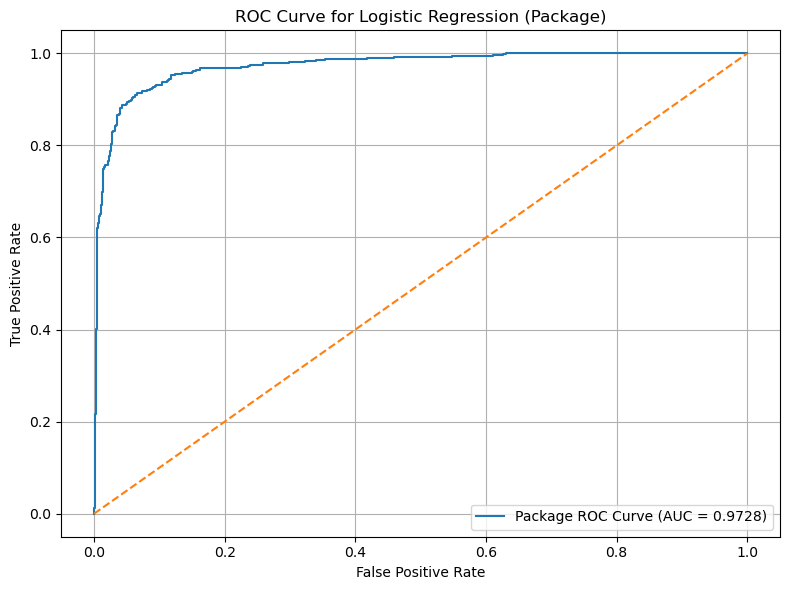


Manual ROC Points:
    Threshold       FPR       TPR
0         0.0  1.000000  1.000000
1         0.1  0.307030  0.980176
2         0.2  0.167862  0.969163
3         0.3  0.098996  0.931718
4         0.4  0.065997  0.909692
5         0.5  0.043042  0.883260
6         0.6  0.034433  0.850220
7         0.7  0.027260  0.806167
8         0.8  0.015782  0.748899
9         0.9  0.004304  0.618943
10        1.0  0.000000  0.000000


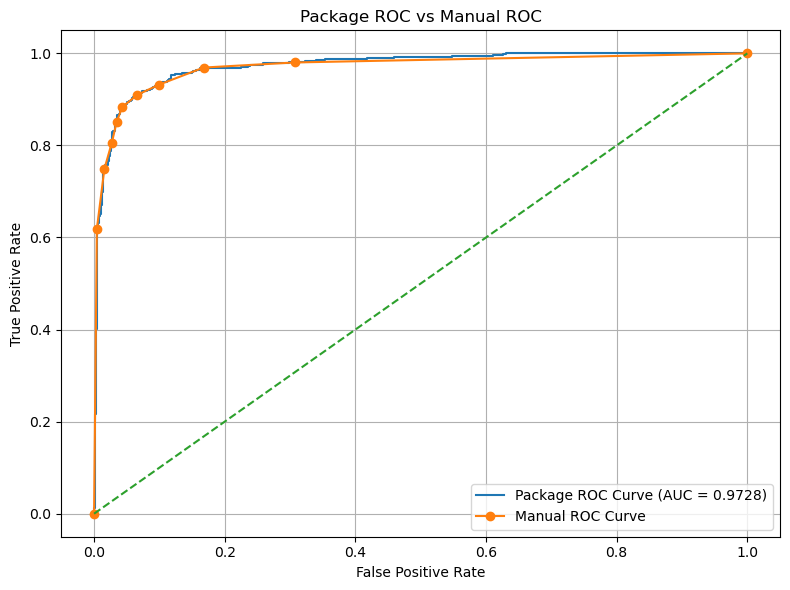

In [6]:
# Problem 3 

# Cross validation for kNN
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_cv_results = []

for k in k_values:
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    acc_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=cv, scoring="accuracy")
    prec_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=cv, scoring="precision")
    rec_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=cv, scoring="recall")
    
    avg_acc = acc_scores.mean()
    avg_error = 1 - avg_acc
    avg_prec = prec_scores.mean()
    avg_rec = rec_scores.mean()
    
    knn_cv_results.append({
        "k": k,
        "Validation Accuracy": avg_acc,
        "Validation Error": avg_error,
        "Validation Precision": avg_prec,
        "Validation Recall": avg_rec
    })

knn_cv_df = pd.DataFrame(knn_cv_results)
print("Cross-validation results for kNN:")
print(knn_cv_df)

best_k = knn_cv_df.loc[knn_cv_df["Validation Error"].idxmin(), "k"]
print("\nBest k:", best_k)

# Train all 3 classifiers
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=10000))
])

lda_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=int(best_k)))
])

models = {
    "Logistic Regression": log_model,
    "LDA": lda_model,
    "kNN": knn_model
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Train Error": 1 - train_acc,
        "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
        "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
        "Test Accuracy": test_acc,
        "Test Error": 1 - test_acc,
        "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_test_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)
print("\nTraining and Testing Results:")
print(results_df)

# ROC curve with package for Logistic Regression
log_model.fit(X_train, y_train)
y_prob = log_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds_pkg = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("\nAUC for Logistic Regression:", auc_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Package ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression (Package)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Manual ROC curve without package
manual_thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

manual_points = []

for t in manual_thresholds:
    y_pred_manual = (y_prob >= t).astype(int)
    
    TP = np.sum((y_test == 1) & (y_pred_manual == 1))
    TN = np.sum((y_test == 0) & (y_pred_manual == 0))
    FP = np.sum((y_test == 0) & (y_pred_manual == 1))
    FN = np.sum((y_test == 1) & (y_pred_manual == 0))
    
    if (FP + TN) == 0:
        fpr_manual = 0
    else:
        fpr_manual = FP / (FP + TN)
        
    if (TP + FN) == 0:
        tpr_manual = 0
    else:
        tpr_manual = TP / (TP + FN)
    
    manual_points.append({
        "Threshold": t,
        "FPR": fpr_manual,
        "TPR": tpr_manual
    })

manual_roc_df = pd.DataFrame(manual_points)
print("\nManual ROC Points:")
print(manual_roc_df)

# Plotting 
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Package ROC Curve (AUC = {auc_score:.4f})")
plt.plot(manual_roc_df["FPR"], manual_roc_df["TPR"], marker="o", label="Manual ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Package ROC vs Manual ROC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# Problem 4

def create_folds(X, y, k):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)
    return folds

def manual_cross_validation(model, X, y, k):
    folds = create_folds(X, y, k)
    errors = []

    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        error = 1 - accuracy_score(y_val, y_pred)
        errors.append(error)

        print(f"Fold {i+1}/{k} Validation Error: {error:.4f}")

    avg_error = np.mean(errors)
    return avg_error

# Run for k = 5 and 10
k_values = [5, 10]

for k in k_values:
    print(f"\nResults for k = {k}")

    log_error = manual_cross_validation(LogisticRegression(max_iter=10000), X, y, k)
    lda_error = manual_cross_validation(LinearDiscriminantAnalysis(), X, y, k)

    print(f"\nAverage Validation Error for Logistic Regression (k={k}): {log_error:.4f}")
    print(f"Average Validation Error for LDA (k={k}): {lda_error:.4f}")


Results for k = 5
Fold 1/5 Validation Error: 0.0673
Fold 2/5 Validation Error: 0.0707
Fold 3/5 Validation Error: 0.0804
Fold 4/5 Validation Error: 0.0750
Fold 5/5 Validation Error: 0.0685
Fold 1/5 Validation Error: 0.1183
Fold 2/5 Validation Error: 0.1130
Fold 3/5 Validation Error: 0.1250
Fold 4/5 Validation Error: 0.1043
Fold 5/5 Validation Error: 0.1076

Average Validation Error for Logistic Regression (k=5): 0.0724
Average Validation Error for LDA (k=5): 0.1137

Results for k = 10
Fold 1/10 Validation Error: 0.0672
Fold 2/10 Validation Error: 0.0913
Fold 3/10 Validation Error: 0.0717
Fold 4/10 Validation Error: 0.0761
Fold 5/10 Validation Error: 0.0717
Fold 6/10 Validation Error: 0.0478
Fold 7/10 Validation Error: 0.0674
Fold 8/10 Validation Error: 0.0783
Fold 9/10 Validation Error: 0.0761
Fold 10/10 Validation Error: 0.0717
Fold 1/10 Validation Error: 0.1171
Fold 2/10 Validation Error: 0.1065
Fold 3/10 Validation Error: 0.0870
Fold 4/10 Validation Error: 0.1217
Fold 5/10 Validatio